# AI Zero to Hero: Introduction to Google Colab

This practical converts the slide material into a guided, executable Colab notebook.

## Learning outcomes
- Create, rename and save a Colab notebook.
- Connect Google Drive and create course folders.
- Load and save CSV and Excel files.
- Use code cells, text cells, variables and packages.
- Complete a small analysis using `mtcars`.
- Save a modified dataset and a figure.

> Suggested filename: `AI_Zero_To_Hero_Session_1_1.ipynb`


## 1. Colab basics

Open `colab.research.google.com`, sign in, and choose **File > New notebook**.

- **Code cells** contain executable Python.
- **Text cells** contain Markdown headings, explanations and notes.
- Run a cell with the play button or **Shift+Enter**.


## 2. Connect Google Drive
Run this cell in Colab and approve the access request.


## 3. Create the course folder structure
Google Drive is normally mounted at `/content/drive/MyDrive/`.


In [23]:
from pathlib import Path
course_folder = Path('Lab1_workspace')
data_folder = course_folder / 'Data'
notebooks_folder = course_folder / 'Notebooks'
figures_folder = course_folder / 'Figures'
for folder in [course_folder, data_folder, notebooks_folder, figures_folder]:
    folder.mkdir(parents=True, exist_ok=True)
print('Course folder:', course_folder)

Course folder: Lab1_workspace


### View your Drive folders
Your own folder names will differ.


In [24]:
my_drive = Path('.')
print([item.name for item in my_drive.iterdir()] if my_drive.exists() else 'Mount Drive first.')


['.ipynb_checkpoints', 'Data', 'Day1_Lab1_Introduction_Colabs.ipynb', 'Day1_Lab2_Exploring_Data_Part1.ipynb', 'Day1_Lab2_Exploring_Data_Part2.ipynb', 'Day1_Lab3_Clustering.ipynb', 'Day2_Lab5_Classification.ipynb', 'Day2_Lab6_Regression.ipynb', 'End_Of_Course_Assessment_Diabetes_Fixed.ipynb', 'Lab1_workspace']


## 4. Your first code cell


In [25]:
print('Hello AI Zero To Hero')


Hello AI Zero To Hero


### Try it
Edit the message in the next cell and run it again.


In [26]:
print('Hello World!')


Hello World!


## 5. Practise Markdown
Insert a text cell and enter:

```markdown
# My notes
I have learned how to use code and text cells.
- First point
- Second point
```


B to add a new cell, use M for md and Y for code

## 6. Variables and calculations


In [27]:
course = 'AI Zero To Hero'
year = 2026
print(course)
print(year)


AI Zero To Hero
2026


In [28]:
x = 10
y = 4
print('Addition:', x + y)
print('Subtraction:', x - y)
print('Multiplication:', x * y)
print('Division:', x / y)


Addition: 14
Subtraction: 6
Multiplication: 40
Division: 2.5


### Run cells in order
The second cell depends on a variable created in the first.


In [29]:
hours = 6


In [30]:
mark = 40 + 5 * hours
print(mark)


70


## 7. Import packages
`pandas` handles data tables, `matplotlib` creates figures, and `numpy` supports numerical operations.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('Packages loaded')


Packages loaded


## 8. Loading files from Drive
These examples run only when the named files exist.


In [32]:
csv_file = data_folder / 'drugcosts.csv'
if csv_file.exists():
    drugcosts = pd.read_csv(csv_file)
    display(drugcosts.head())
else:
    print('File not found:', csv_file)


,CostOfDrug
0,2.0
1,4.0
2,6.2
3,8.0
4,8.0


In [33]:
excel_file = data_folder / 'drugcosts.xlsx'
if excel_file.exists():
    drugcosts_excel = pd.read_excel(excel_file)
    display(drugcosts_excel.head())
else:
    print('File not found:', excel_file)


,CostOfDrug
0,2.0
1,4.0
2,6.2
3,8.0
4,8.0


In [34]:
print('Files in data_folder:')
for item in data_folder.iterdir():
    if item.is_file():
        print(item.name)

Files in data_folder:
drugcosts.csv
drugcosts.xlsx
iris.csv
mtcars.csv
updated_costs.csv
updated_costs2.csv
wnv.csv


In [35]:
print(data_folder)

Lab1_workspace\Data


### Create and save a category
If `drugcosts.csv` contains `CostOfDrug`, classify values above 100 as Expensive.


In [36]:
if 'drugcosts' in globals() and 'CostOfDrug' in drugcosts.columns:
    drugcosts['Category'] = np.where(drugcosts['CostOfDrug'] > 100, 'Expensive', 'Standard')
    updated_file = data_folder / 'updated_costs.csv'
    drugcosts.to_csv(updated_file, index=False)
    print('Saved:', updated_file)
else:
    print('Load a file containing CostOfDrug first.')


Saved: Lab1_workspace\Data\updated_costs.csv


# Complete example using `mtcars`

Variables:
- `mpg`: miles per gallon
- `wt`: weight in thousands of pounds
- `hp`: gross horsepower


## 9. Create the dataset


In [37]:
mtcars = pd.DataFrame({
    'mpg': [21.0, 21.0, 22.8, 21.4, 18.7, 18.1, 14.3, 24.4],
    'wt': [2.620, 2.875, 2.320, 3.215, 3.440, 3.460, 3.570, 3.190],
    'hp': [110, 110, 93, 110, 175, 105, 245, 62]
})
mtcars


,mpg,wt,hp
0,21.0,2.620,110
1,21.0,2.875,110
2,22.8,2.320,93
3,21.4,3.215,110
4,18.7,3.440,175
5,18.1,3.460,105
6,14.3,3.570,245
7,24.4,3.190,62


In [38]:
mtcars_data = pd.read_csv(data_folder / 'mtcars.csv')
mtcars_data.head()


,mpg,wt,hp
0,21.0,2.620,110
1,21.0,2.875,110
2,22.8,2.320,93
3,21.4,3.215,110
4,18.7,3.440,175


In [39]:
display(mtcars_data)

,mpg,wt,hp
0,21.0,2.620,110
1,21.0,2.875,110
2,22.8,2.320,93
3,21.4,3.215,110
4,18.7,3.440,175
5,18.1,3.460,105
6,14.3,3.570,245
7,24.4,3.190,62


## 10. Save and reload the dataset


In [40]:
source_file = data_folder / 'mtcars.csv'
mtcars.to_csv(source_file, index=False)
print('Saved:', source_file)


Saved: Lab1_workspace\Data\mtcars.csv


In [41]:
mtcars_data = pd.read_csv(source_file)
mtcars_data.head()


,mpg,wt,hp
0,21.0,2.620,110
1,21.0,2.875,110
2,22.8,2.320,93
3,21.4,3.215,110
4,18.7,3.440,175


## 11. Explore the data


In [42]:
print('Shape:', mtcars_data.shape)
print('Columns:', mtcars_data.columns.tolist())
mtcars_data.head()


Shape: (8, 3)
Columns: ['mpg', 'wt', 'hp']


,mpg,wt,hp
0,21.0,2.620,110
1,21.0,2.875,110
2,22.8,2.320,93
3,21.4,3.215,110
4,18.7,3.440,175


In [43]:
mtcars_data.describe()


,mpg,wt,hp
count,8.000000,8.000000,8.000000
mean,20.212500,3.086250,126.250000
std,3.130238,0.443257,57.265672
min,14.300000,2.320000,62.000000
25%,18.550000,2.811250,102.000000
50%,21.000000,3.202500,110.000000
75%,21.750000,3.445000,126.250000
max,24.400000,3.570000,245.000000


Discuss: How many observations are present? What are the ranges of `mpg`, `wt` and `hp`?


## 12. Calculate average fuel consumption


In [44]:
mean_mpg = mtcars_data['mpg'].mean()
print(f'Average fuel consumption: {mean_mpg:.4f} miles per gallon')


Average fuel consumption: 20.2125 miles per gallon


## 13. Find the highest-horsepower observation


In [45]:
highest_hp_row = mtcars_data.loc[mtcars_data['hp'].idxmax()]
highest_hp_row


mpg     14.30
wt       3.57
hp     245.00
Name: 6, dtype: float64

What `mpg` and `wt` values are associated with the highest horsepower?


## 14. Plot fuel consumption against weight


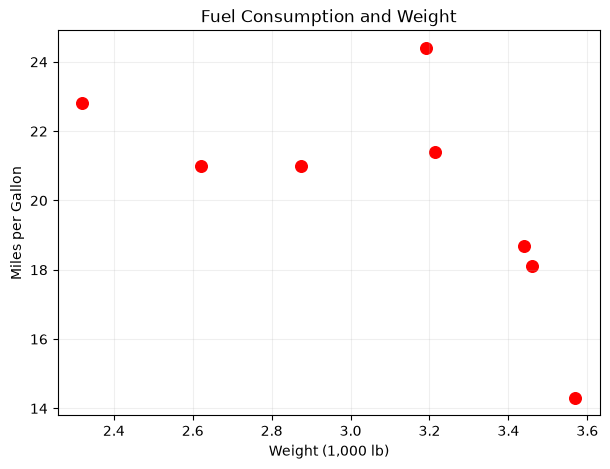

In [46]:
plt.figure(figsize=(7, 5))
plt.scatter(mtcars_data['wt'], mtcars_data['mpg'], color='red', s=70)
plt.xlabel('Weight (1,000 lb)')
plt.ylabel('Miles per Gallon')
plt.title('Fuel Consumption and Weight')
plt.grid(alpha=0.2)
plt.show()


Does fuel consumption appear to decrease as vehicle weight increases?


## 15. Create a vehicle size category
- Light: up to 2.8
- Medium: above 2.8 and up to 3.3
- Heavy: above 3.3


In [47]:
mtcars_data['size'] = pd.cut(
    mtcars_data['wt'], bins=[0, 2.8, 3.3, float('inf')],
    labels=['Light', 'Medium', 'Heavy'], include_lowest=True
)
mtcars_data


,mpg,wt,hp,size
0,21.0,2.620,110,Light
1,21.0,2.875,110,Medium
2,22.8,2.320,93,Light
3,21.4,3.215,110,Medium
4,18.7,3.440,175,Heavy
5,18.1,3.460,105,Heavy
6,14.3,3.570,245,Heavy
7,24.4,3.190,62,Medium


## 16. Save the modified dataset


In [48]:
modified_file = data_folder / 'mtcars_modified.csv'
mtcars_data.to_csv(modified_file, index=False)
print('Saved:', modified_file)


Saved: Lab1_workspace\Data\mtcars_modified.csv


## 17. Save the scatter plot


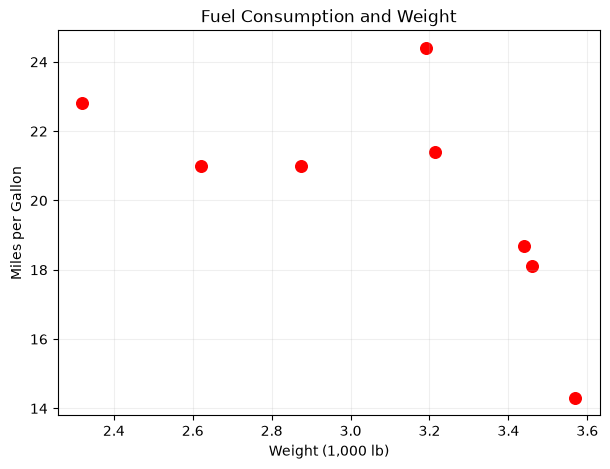

Saved: Lab1_workspace\Figures\mtcars_scatterplot.png


In [49]:
figure_file = figures_folder / 'mtcars_scatterplot.png'
plt.figure(figsize=(7, 5))
plt.scatter(mtcars_data['wt'], mtcars_data['mpg'], color='red', s=70)
plt.xlabel('Weight (1,000 lb)')
plt.ylabel('Miles per Gallon')
plt.title('Fuel Consumption and Weight')
plt.grid(alpha=0.2)
plt.savefig(figure_file, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', figure_file)


## 18. Check the saved files


In [50]:
print('Data files:', sorted(p.name for p in data_folder.glob('mtcars*')))
print('Figure files:', sorted(p.name for p in figures_folder.glob('mtcars*')))


Data files: ['mtcars.csv', 'mtcars_modified.csv']
Figure files: ['mtcars_scatterplot.png']


# Exercise and questions

Complete the whole workflow, then add a text cell answering:
1. What is the average `mpg`?
2. Which observation has the highest `hp`?
3. Does `mpg` appear to decrease as weight increases?
4. Why is saving directly to Google Drive useful?
5. What is the difference between a code cell and a text cell?


## My answers

**1.** The average `mpg` is 20.2125 miles per gallon (from `mtcars_data['mpg'].mean()`).

**2.** The observation with the highest `hp` is row 6: `hp` = 245, with `mpg` = 14.3 and `wt` = 3.57.

**3.** Yes. In the scatter plot the points trend downwards: heavier vehicles have lower `mpg`. The correlation is about -0.63, a moderate negative relationship (only 8 vehicles, so it is a rough trend).

**4.** Saving directly to Google Drive keeps files in the cloud, so they are not lost when the Colab session ends, can be reopened in later sessions, and can be accessed from any device or shared with others.

**5.** A code cell contains Python that is run and produces output. A text cell contains Markdown for notes, headings and explanations, which is displayed but not executed.

# Summary
You have mounted Drive, created folders, used Markdown and Python cells, loaded and saved data, explored `mtcars`, created a variable, produced a graph, and saved the outputs.
